<a href="https://colab.research.google.com/github/channel1umut-lang/Machine-Learning-Applications/blob/main/0002_MultipleLinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DataSets/2-multiplegradesdataset.csv')

In [ ]:
df.head()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
0,4.7,7.3,82.9,3.3,80.7
1,3.8,6.6,87.9,3.3,76.0
2,5.0,6.3,88.3,2.3,89.1
3,6.3,7.6,86.0,3.2,95.9
4,3.6,8.0,89.2,3.3,70.5


In [ ]:
df.describe()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
count,50.00000,50.000000,50.000000,50.00000,50.00000
mean,3.66800,7.022000,89.736000,3.09000,76.07000
std,1.40123,0.874419,4.924813,0.89699,11.70915
min,1.10000,4.400000,80.400000,1.50000,56.90000
25%,2.67500,6.500000,85.625000,2.22500,68.07500
50%,3.60000,7.050000,90.100000,3.20000,73.55000
75%,4.50000,7.575000,92.550000,3.57500,84.17500
max,6.80000,8.600000,100.000000,5.70000,100.00000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Study Hours         50 non-null     float64
 1   Sleep Hours         50 non-null     float64
 2   Attendance Rate     50 non-null     float64
 3   Social Media Hours  50 non-null     float64
 4   Exam Score          50 non-null     float64
dtypes: float64(5)
memory usage: 2.1 KB


In [ ]:
df.isnull().sum()

,0
Study Hours,0
Sleep Hours,0
Attendance Rate,0
Social Media Hours,0
Exam Score,0


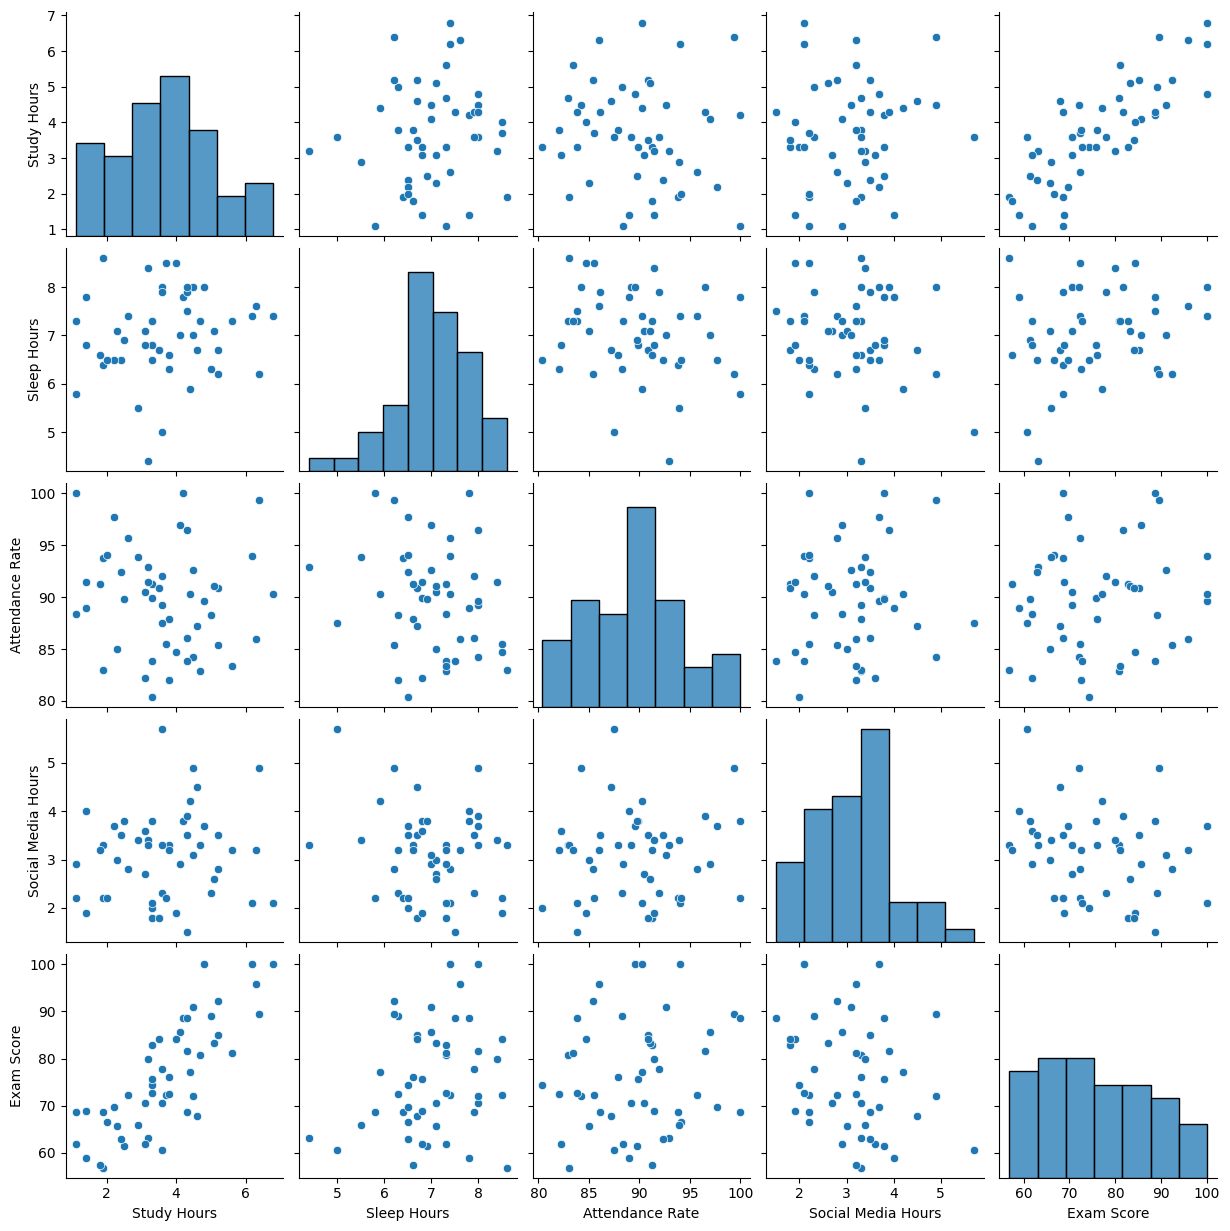

In [ ]:
sns.pairplot(df)
plt.show()

In [ ]:
df.corr()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
Study Hours,1.000000,0.114015,-0.112860,0.115023,0.804266
Sleep Hours,0.114015,1.000000,-0.222024,-0.177166,0.227694
Attendance Rate,-0.112860,-0.222024,1.000000,0.068272,0.123791
Social Media Hours,0.115023,-0.177166,0.068272,1.000000,-0.248743
Exam Score,0.804266,0.227694,0.123791,-0.248743,1.000000


Text(0, 0.5, 'Exam Score')

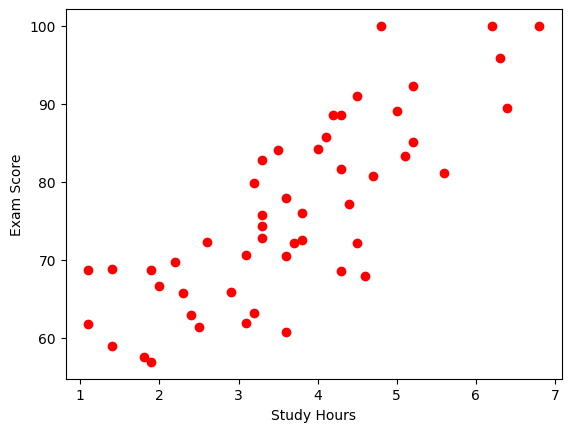

In [ ]:
plt.scatter(df['Study Hours'], df['Exam Score'] , color = 'red')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')

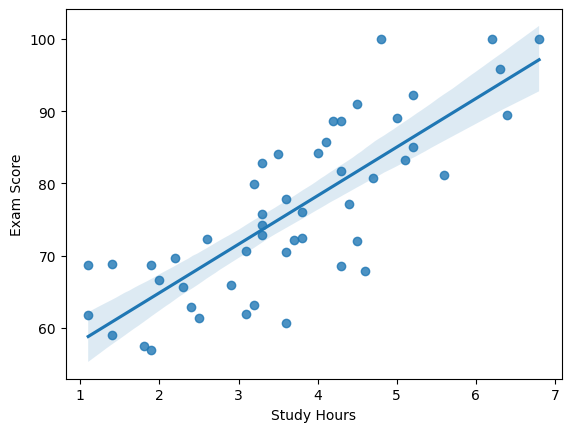

In [ ]:
sns.regplot(x = df['Study Hours'], y = df['Exam Score'])
plt.show()

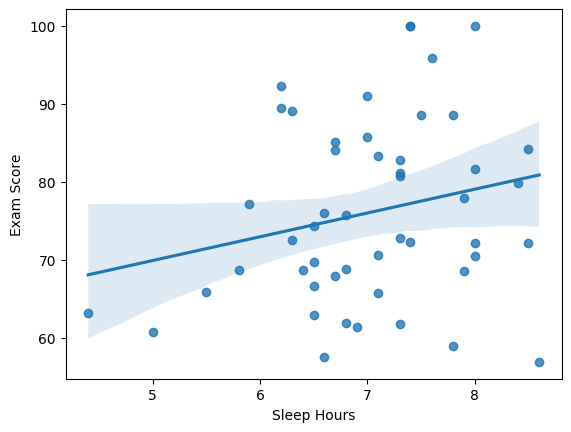

In [ ]:
sns.regplot(x = df['Sleep Hours'], y = df['Exam Score'])
plt.show()

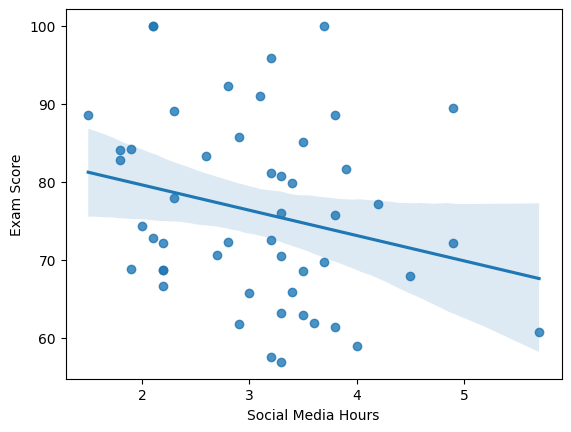

In [ ]:
sns.regplot(x = df['Social Media Hours'], y = df['Exam Score'])
plt.show()

In [ ]:
df.tail()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
45,2.9,5.5,93.9,3.4,65.9
46,3.3,7.3,83.8,2.1,72.8
47,5.6,7.3,83.4,3.2,81.1
48,4.5,7.0,92.6,3.1,91.0
49,1.4,6.8,91.5,1.9,68.8


In [ ]:
#indipendnet and dependent features

In [ ]:
X = df.iloc[:,:-1] #Alttaki kod ile ayni sey
y = df.iloc[:,-1]

#X = df[['Study Hours', 'Sleep Hours', 'Attendance Rate','Social Media Hours']]
#y = df['Exam Score']

In [ ]:
X.head()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours
0,4.7,7.3,82.9,3.3
1,3.8,6.6,87.9,3.3
2,5.0,6.3,88.3,2.3
3,6.3,7.6,86.0,3.2
4,3.6,8.0,89.2,3.3


In [ ]:
y.head()

,Exam Score
0,80.7
1,76.0
2,89.1
3,95.9
4,70.5


In [ ]:
#train-test split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train=scaler.fit_transform(X_train) #Kolonlarin kendi aralarindaki agirliklari daha iyi hesapliyoruz ve gradiant decent daha iyi calisiyor
X_test=scaler.transform(X_test)

In [ ]:
X_train

array([[ 7.64922342e-01,  1.07637448e+00,  2.70413080e-03,
         6.75932027e-01],
       [-1.60676425e+00, -3.94765312e-01,  3.42883785e-01,
         1.46070057e-01],
       [ 1.39737210e+00,  3.40804586e-01, -1.23795108e+00,
         1.46070057e-01],
       [-1.92298913e+00, -1.84602484e-01,  3.82904921e-01,
        -1.23157107e+00],
       [ 2.11528804e-01,  2.55603439e-02,  1.48348616e+00,
        -1.71847126e-01],
       [ 2.90585024e-01,  8.66211656e-01,  2.08380319e+00,
         7.81904421e-01],
       [-2.56398550e-02, -7.10009554e-01, -1.51809903e+00,
         1.46070057e-01],
       [ 9.23034781e-01, -7.10009554e-01, -2.57433252e-01,
        -8.07681490e-01],
       [-4.20920953e-01,  3.40804586e-01, -1.15790881e+00,
        -1.01962628e+00],
       [-2.56398550e-02, -3.94765312e-01, -3.37475524e-01,
         2.52042451e-01],
       [ 3.69641243e-01,  5.50967414e-01, -1.15790881e+00,
        -1.65546064e+00],
       [-9.74314491e-01,  4.45886000e-01,  1.22334877e+00,
      

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
regression = LinearRegression()

In [ ]:
regression.fit(X_train, y_train)  #bu adimdan sonra yeni bir ogrenci gelseydi onu predict edebiliriz

LinearRegression()

In [ ]:
X_train[0]

array([0.76492234, 1.07637448, 0.00270413, 0.67593203])

In [ ]:
df.iloc[0]

,0
Study Hours,4.7
Sleep Hours,7.3
Attendance Rate,82.9
Social Media Hours,3.3
Exam Score,80.7


In [ ]:
#Manuel Prediction

In [ ]:
new_student = [[5,7,90,4]] # yeni ogrenciyi girdi olarak veriyoruz. Kac alacagini tahmin ediyoruz. 5 = study hour, 7 = sleep hour, 90 = attendance rate, 2 = social medyada takildi

In [ ]:
new_student_scaled = scaler.transform(new_student)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
regression.predict(new_student_scaled)

array([82.23465969])

In [ ]:
#prediction

In [ ]:
y_pred=regression.predict(X_test)

In [ ]:
y_pred

array([ 67.04704385,  57.90545589,  83.63084813,  63.69399367,
        69.73079557,  80.76485587,  93.76445033,  65.93953528,
        64.58675718,  78.42296106,  56.67860558,  64.44046585,
       102.60438643])

In [ ]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("mse: ", mse)
print("mae: ", mae)
print("rmse: ", rmse)

mse:  14.600589378986257
mae:  3.277026485962786
rmse:  3.8210717578954543


In [ ]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print("r2 score: ", score)
#adjusted R-squared
print('adjusted R-squared:', 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

r2 score:  0.915670734577271
adjusted R-squared: 0.8735061018659065


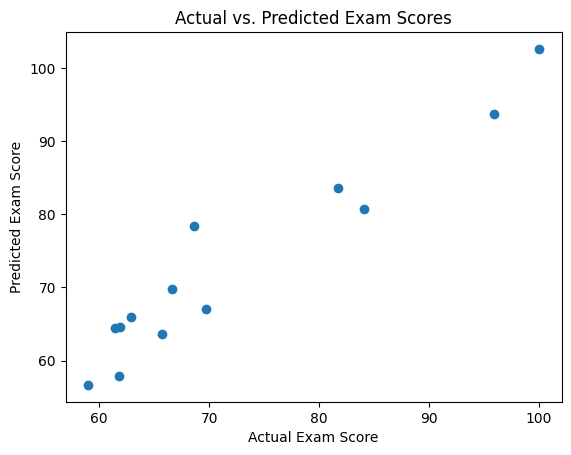

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs. Predicted Exam Scores')
plt.show()

In [ ]:
y_test

,Exam Score
35,69.7
37,61.8
41,81.7
26,65.7
38,66.6
43,84.1
3,95.9
33,62.9
30,61.9
36,68.6


In [ ]:
y_pred

array([ 67.04704385,  57.90545589,  83.63084813,  63.69399367,
        69.73079557,  80.76485587,  93.76445033,  65.93953528,
        64.58675718,  78.42296106,  56.67860558,  64.44046585,
       102.60438643])

In [ ]:
residuals = y_test - y_pred

In [ ]:
residuals

,Exam Score
35,2.652956
37,3.894544
41,-1.930848
26,2.006006
38,-3.130796
43,3.335144
3,2.135550
33,-3.039535
30,-2.686757
36,-9.822961


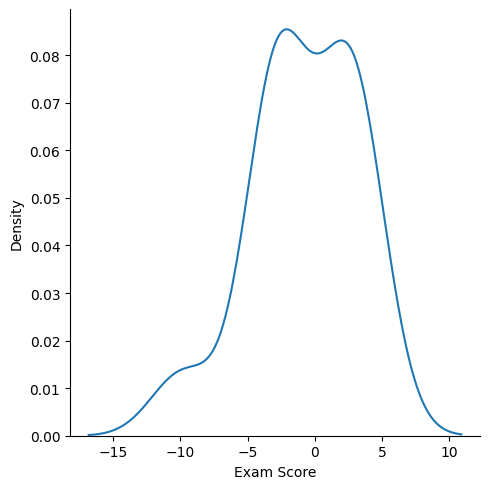

In [ ]:
## if residuals are in normal distribution it seems good
sns.displot(residuals,kind='kde')
plt.show()

In [ ]:
regression.coef_ #agirligi

array([ 9.28014703,  1.78967062,  3.24340001, -4.08127695])

In [ ]:
regression.intercept_

np.float64(77.41081081081082)

In [ ]:
X.head()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours
0,4.7,7.3,82.9,3.3
1,3.8,6.6,87.9,3.3
2,5.0,6.3,88.3,2.3
3,6.3,7.6,86.0,3.2
4,3.6,8.0,89.2,3.3


In [ ]:
new_student

[[5, 7, 90, 4]]

In [ ]:
students =[
   [6, 8, 95, 5],
    [3, 6, 85, 4],
    [4, 7, 80, 3]
]

In [ ]:
predicted_scores = regression.predict(scaler.transform(students)) #ilk ogrenci 90, ikincisi 62, 3.su de 72 almis
print(predicted_scores)

[90.37189122 62.43586785 72.73292556]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
